In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

data = pd.read_csv("../data/data_transformed_part3.csv")
# data = data[data["Источник"] != "cian.ru"].copy()
data.head()

,ID на сайте,Источник,Цена,Дата,Тип автора,Город,Метро/Район,Адрес,Описание,lat,lng,URL,Ссылки на картинки,"Расстояние до метро, км",Категория,Вид объекта,Общая площадь,Этаж,Этажность здания
0,319074125,cian.ru,61290,2025-06-25 02:37:01,Агентство,Чехов муниципальный округ,NaN,51,НАЗВАНИЕ: Коммерческая земля в Московская обла...,55.147963,37.300539,https://www.cian.ru/rent/commercial/319074125,https://images.cdn-cian.ru/images/2538528701-1...,NaN,Сельхозназначение,Коммерческая земля,979.0,NaN,NaN
1,7502945913,avito.ru,30000,2025-07-22 15:29:04,Частное лицо (фильтр),Коломна,NaN,"Московская обл., г.о. Коломна, с. Коробчеево, ...",НАЗВАНИЕ: Аренда складского помещения (120 кв....,55.089271,38.907821,https://www.avito.ru/kolomna/kommercheskaya_ne...,https://30.img.avito.st/image/1/1.FBqWE7a5uPOg...,NaN,NaN,Складское помещение,120.0,1.0,NaN
2,7496745927,avito.ru,6317999,2025-07-28 23:07:46,Агентство,Раменское,Ипподром,"Московская обл., Раменский муниципальный округ...",НАЗВАНИЕ: Аренда складского помещения 5400 м2\...,55.561726,38.247660,https://www.avito.ru/ramenskoe/kommercheskaya_...,https://80.img.avito.st/image/1/1.gcNntLa5LSpR...,NaN,NaN,Складское помещение,5400.0,NaN,NaN
3,7461393980,avito.ru,650833,2025-06-11 11:35:35,Частное лицо (фильтр),Солнечногорск,NaN,"Московская обл., Солнечногорск, ул. Разина, 10",НАЗВАНИЕ: Склад\n\nОПИСАНИЕ: Склад под аренду ...,56.169849,36.982052,https://www.avito.ru/solnechnogorsk/kommerches...,https://90.img.avito.st/image/1/1.K2nHyLa5h4Dx...,NaN,NaN,Складское помещение,1420.0,1.0,NaN
4,319916802,cian.ru,349957,2025-07-19 14:25:32,Агентство,Солнечногорск городской округ,Зеленоград — Крюково,37,НАЗВАНИЕ: Коммерческая земля в Московская обла...,56.115098,37.197206,https://www.cian.ru/rent/commercial/319916802,https://images.cdn-cian.ru/images/kommercheski...,25.667,NaN,Коммерческая земля,6100.0,NaN,NaN


# -----------------------------------------------------------------------

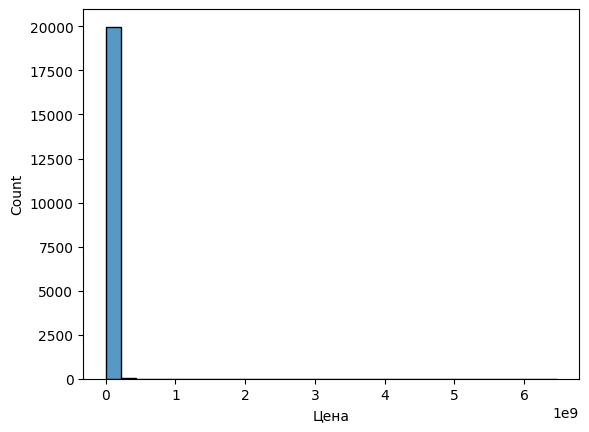

In [2]:
data["Цена"] = data["Цена"].astype(float)
data["Цена / м2"] = data["Цена"] / data["Общая площадь"]
data["Log(Цена)"] = np.log1p(data["Цена"])

sns.histplot(data["Цена"], bins=30)
plt.show()

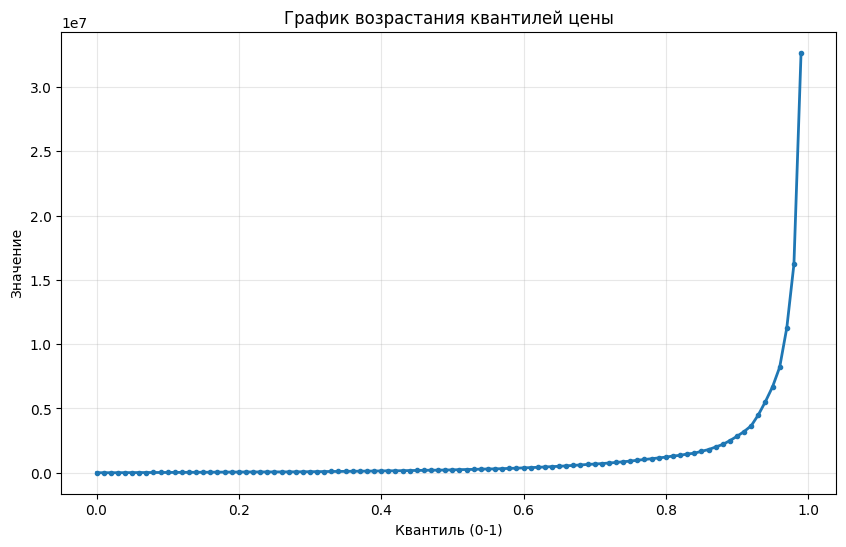

In [3]:
def get_quantplot(series):
    quantiles = np.arange(0, 1.00, 0.01)
    q_values = series.quantile(quantiles)
    
    plt.figure(figsize=(10, 6))
    q_values.plot(kind='line', linewidth=2, marker='o', markersize=3)
    plt.title('График возрастания квантилей цены')
    plt.xlabel('Квантиль (0-1)')
    plt.ylabel('Значение')
    plt.grid(True, alpha=0.3)
    plt.show()

get_quantplot(data["Цена"])

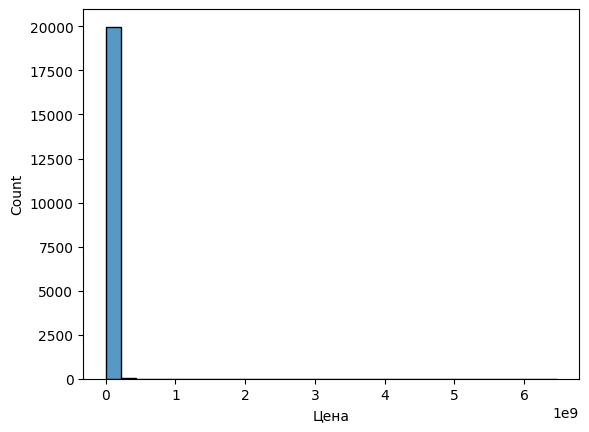

In [4]:
sns.histplot(data["Цена"], bins=30)
plt.show()

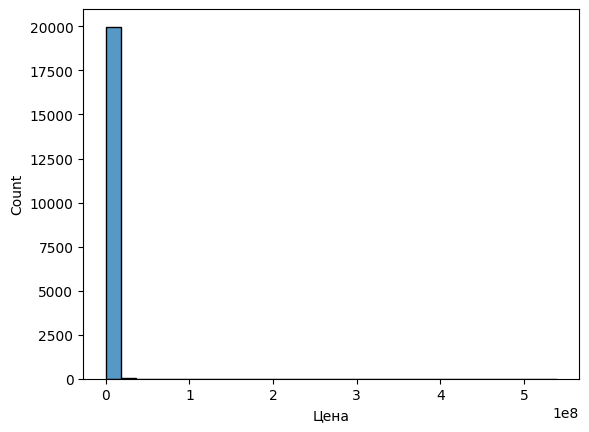

In [5]:
data2 = data.copy()
mask = (data2["Цена"] >= data2["Цена"].quantile(0.97))
data2.loc[mask, "Цена"] /= 12.0
# data2.loc[mask, "Цена"] /= data2.loc[mask, "Общая площадь"]

sns.histplot(data2["Цена"], bins=30)
plt.show()

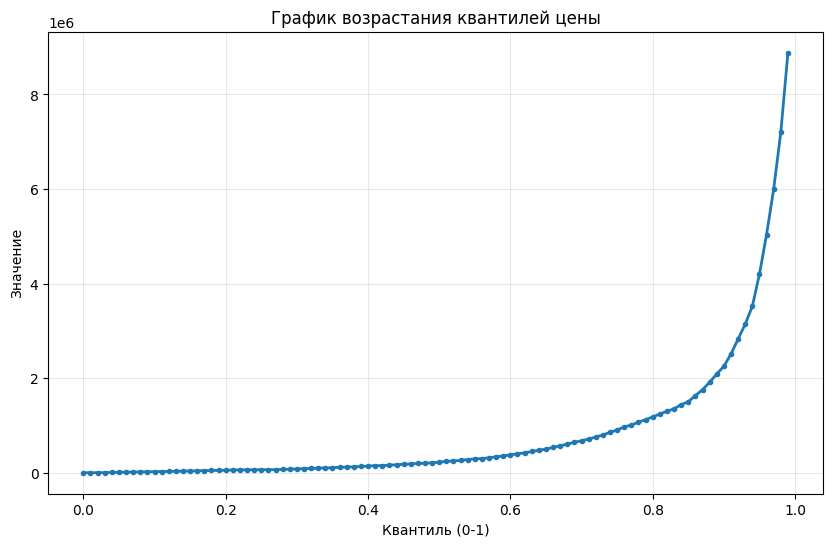

In [6]:
get_quantplot(data2["Цена"])

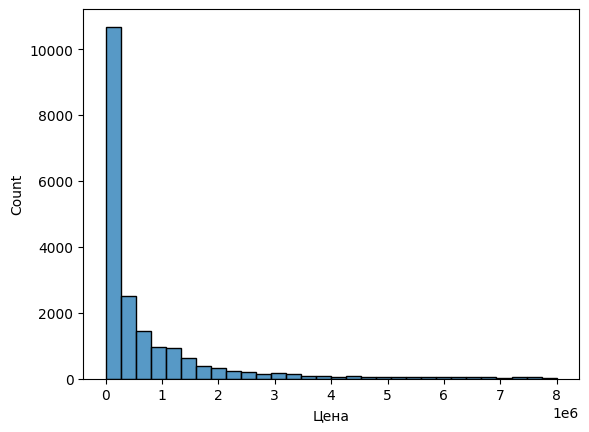

In [7]:
data2 = data2[data2["Цена"] <= 8e6].copy()
sns.histplot(data2["Цена"], bins=30)
plt.show()

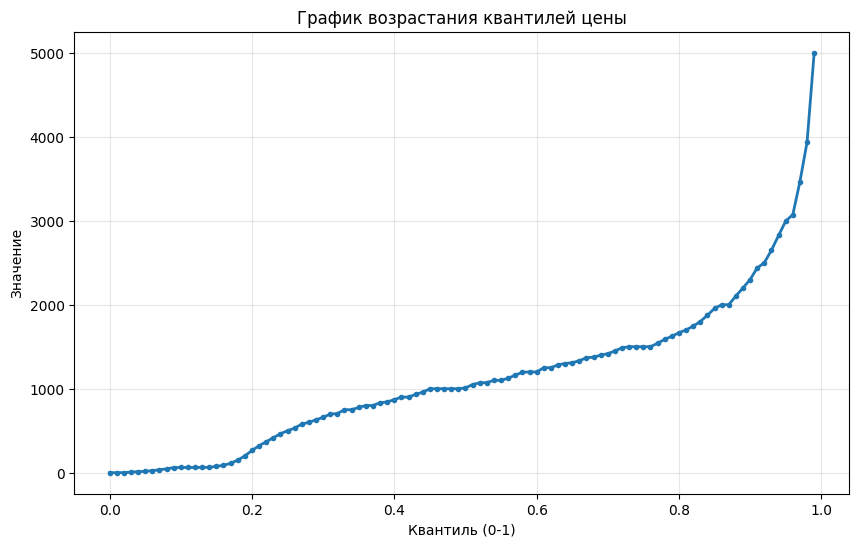

In [8]:
get_quantplot(data2["Цена / м2"])

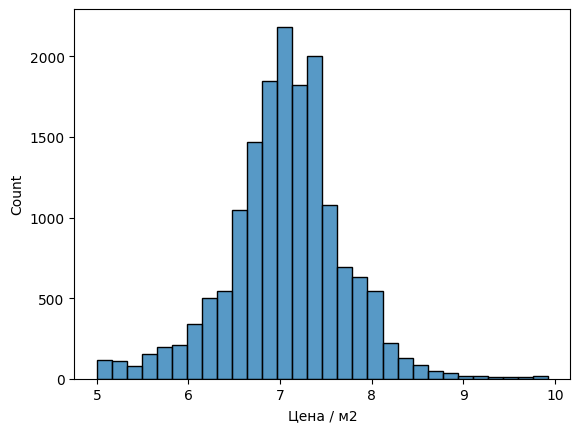

In [9]:
data2 = data2[(np.log1p(data2["Цена / м2"]) <= 10) & (np.log1p(data2["Цена / м2"]) >= 5)].copy()
sns.histplot(np.log1p(data2["Цена / м2"]), bins=30)
plt.show()

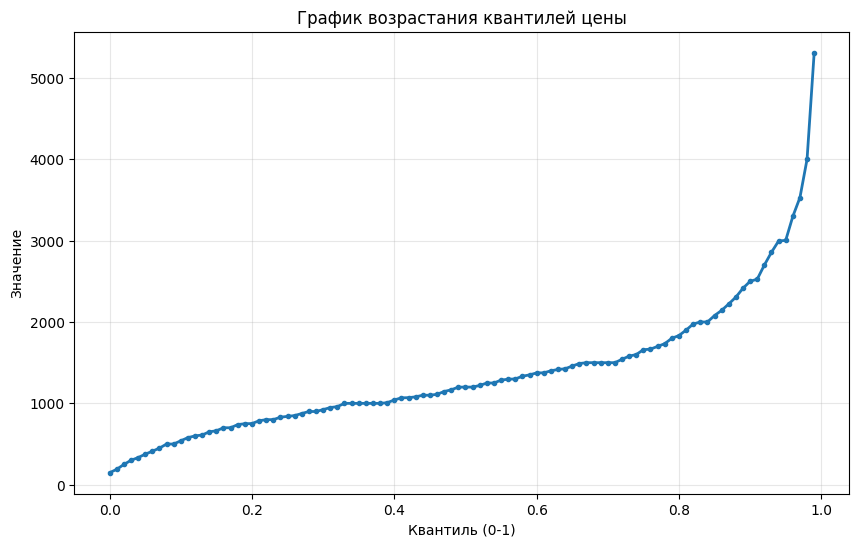

In [10]:
get_quantplot(data2["Цена / м2"])

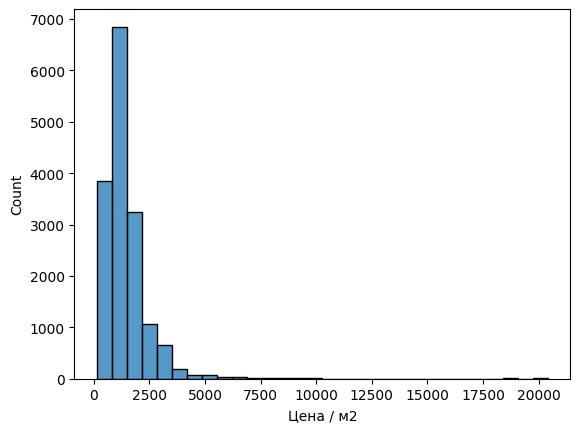

In [11]:
sns.histplot(data2["Цена / м2"], bins=30)
plt.show()

In [12]:
data["Источник"].value_counts()

Источник
cian.ru             10001
avito.ru             7689
realty.yandex.ru     2310
Name: count, dtype: int64

In [13]:
data = data2.copy()

data = data[data["Вид объекта"] != "Коммерческая земля"].copy()
data = data[data["Вид объекта"] != "Производственное помещение"].copy()
data = data[data["Вид объекта"] != "Складское помещение"].copy()
# data = data[data["Вид объекта"] != "Офисное помещение"].copy()
# data = data[data["Вид объекта"] != "Здание"].copy()
data = data[data["Вид объекта"] != "Гостиница"].copy()
data = data[data['Общая площадь'] <= 2000].copy()
data = data[data['Общая площадь'] >= 20].copy()

In [14]:
data["Вид объекта"].value_counts()

Вид объекта
Помещение свободного назначения    4285
Офисное помещение                  2238
Торговое помещение                 1379
Здание                              162
Name: count, dtype: int64

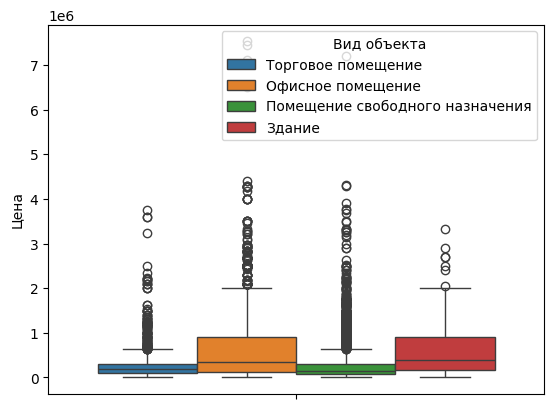

In [15]:
sns.boxplot(data, y="Цена", hue="Вид объекта")
plt.show()

In [16]:
data['Вид объекта'] = data['Вид объекта'].replace(
    {
        'Офисное помещение': 'Офис / Здание',
        'Здание': 'Офис / Здание',
        'Торговое помещение': 'Торговое / Свободное назначение',
        'Помещение свободного назначения': 'Торговое / Свободное назначение'
    }
)

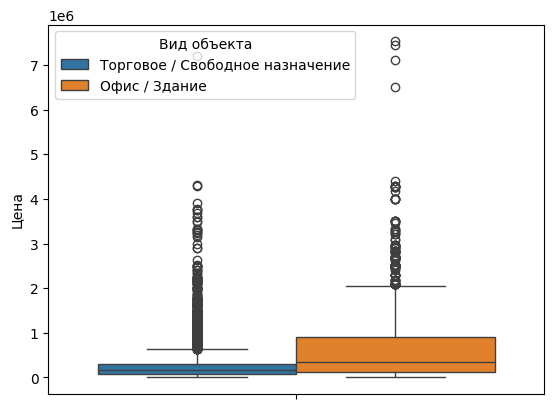

In [17]:
sns.boxplot(data, y="Цена", hue="Вид объекта")
plt.show()

In [18]:
data["Общая площадь"].describe(percentiles=(0.1, 0.25, 0.5, 0.75, 0.9))

count    8252.000000
mean      281.652014
std       378.622216
min        20.000000
10%        31.300000
25%        56.925000
50%       118.850000
75%       342.000000
90%       765.000000
max      2000.000000
Name: Общая площадь, dtype: float64

In [19]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8252 entries, 9 to 19998
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID на сайте              8252 non-null   int64  
 1   Источник                 8252 non-null   object 
 2   Цена                     8252 non-null   float64
 3   Дата                     8252 non-null   object 
 4   Тип автора               8252 non-null   object 
 5   Город                    8252 non-null   object 
 6   Метро/Район              5585 non-null   object 
 7   Адрес                    8206 non-null   object 
 8   Описание                 8252 non-null   object 
 9   lat                      8252 non-null   float64
 10  lng                      8252 non-null   float64
 11  URL                      8252 non-null   object 
 12  Ссылки на картинки       8025 non-null   object 
 13  Расстояние до метро, км  5106 non-null   float64
 14  Категория                0 n

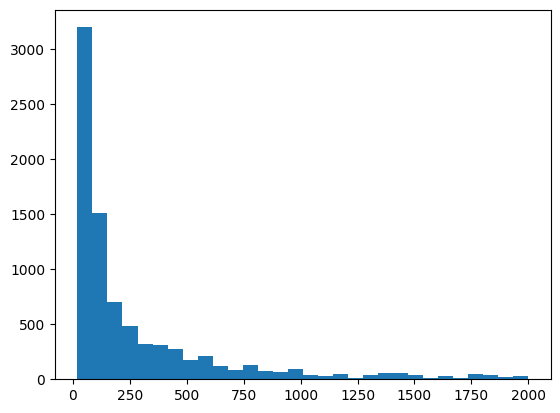

In [20]:
plt.hist(data['Общая площадь'], bins=30)
plt.show()

In [21]:
data = data[data["Цена"] <= 2000000].copy()
data = data[data["Цена"] >= 20000].copy()

n_bins = 10

data['Цена_bin'] = pd.cut(data['Цена'], bins=n_bins)
data['Цена_bin'].value_counts()

Цена_bin
(18020.0, 218000.0]       4445
(218000.0, 416000.0]      1592
(416000.0, 614000.0]       607
(614000.0, 812000.0]       417
(812000.0, 1010000.0]      266
(1010000.0, 1208000.0]     210
(1208000.0, 1406000.0]     167
(1406000.0, 1604000.0]      94
(1604000.0, 1802000.0]      72
(1802000.0, 2000000.0]      49
Name: count, dtype: int64

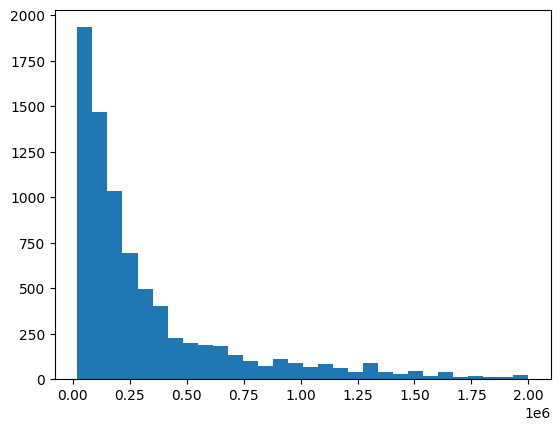

In [22]:
plt.hist(data["Цена"], bins=30)
plt.show()

In [23]:
data["Цена"].describe(percentiles=(0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95)).astype(int)

count       7919
mean      328251
std       371285
min        20000
1%         23000
5%         35000
10%        45000
25%        90000
50%       187000
75%       400000
90%       875999
95%      1200000
max      2000000
Name: Цена, dtype: int64

In [24]:
data.head()

,ID на сайте,Источник,Цена,Дата,Тип автора,Город,Метро/Район,Адрес,Описание,lat,...,Ссылки на картинки,"Расстояние до метро, км",Категория,Вид объекта,Общая площадь,Этаж,Этажность здания,Цена / м2,Log(Цена),Цена_bin
9,7433930500,avito.ru,321301.0,2025-06-10 17:34:54,Агентство,Электросталь,NaN,"Московская обл., Электросталь, ул. Корешкова, 3","НАЗВАНИЕ: Торговая площадь, 96.4 м²\n\nОПИСАНИ...",55.784633,...,https://80.img.avito.st/image/1/1.YWRzmra5zY1F...,NaN,NaN,Торговое / Свободное назначение,96.4,2.0,NaN,3332.997925,12.680137,"(218000.0, 416000.0]"
10,117287608663576318,realty.yandex.ru,195703.0,2025-06-11 07:59:45,Агентство,Химки,Подрезково,"Авиационная улица, 8",НАЗВАНИЕ: Офис (182.9 м²)\n\nОПИСАНИЕ: Помещен...,55.983494,...,https://avatars.mds.yandex.net/get-realty-offe...,15.583,NaN,Офис / Здание,182.9,4.0,8.0,1070.000000,12.184359,"(18020.0, 218000.0]"
11,315859923,cian.ru,260000.0,2025-06-27 20:24:38,Агентство,Люберцы,Некрасовка,"Зенино ЖК Самолет мкр, проезд Некрасовский, 7",НАЗВАНИЕ: Торговая площадь в Московская област...,55.710261,...,https://images.cdn-cian.ru/images/2446134629-1...,2.000,NaN,Торговое / Свободное назначение,118.0,1.0,14.0,2203.389831,12.468441,"(218000.0, 416000.0]"
14,7544327122,avito.ru,180000.0,2025-07-21 13:38:36,Частное лицо (фильтр),Видное,NaN,"Московская обл., Ленинский г.о., д. Коробово, ...","НАЗВАНИЕ: Торговая площадь, 78.8 м²\n\nОПИСАНИ...",55.528539,...,https://00.img.avito.st/image/1/1.koliQLa5PmBU...,NaN,NaN,Торговое / Свободное назначение,78.8,1.0,NaN,2284.263959,12.100718,"(18020.0, 218000.0]"
15,7536314376,avito.ru,1513000.0,2025-07-21 22:59:42,Частное лицо (фильтр),Видное,NaN,"Московская обл., Ленинский г.о., с. Булатников...","НАЗВАНИЕ: Автосервис\n\nОПИСАНИЕ: Автoсеpвиc, ...",55.557146,...,https://50.img.avito.st/image/1/1.rZL_Qba5AXvJ...,NaN,NaN,NaN,890.0,1.0,NaN,1700.000000,14.229606,"(1406000.0, 1604000.0]"


In [25]:
data.isna().sum() / data.shape[0]

ID на сайте                0.000000
Источник                   0.000000
Цена                       0.000000
Дата                       0.000000
Тип автора                 0.000000
Город                      0.000000
Метро/Район                0.322642
Адрес                      0.005051
Описание                   0.000000
lat                        0.000000
lng                        0.000000
URL                        0.000000
Ссылки на картинки         0.028160
Расстояние до метро, км    0.381488
Категория                  1.000000
Вид объекта                0.022478
Общая площадь              0.000000
Этаж                       0.024624
Этажность здания           0.483016
Цена / м2                  0.000000
Log(Цена)                  0.000000
Цена_bin                   0.000000
dtype: float64

In [26]:
data = data.drop(["Категория", "Цена_bin"], axis=1)

In [27]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7919 entries, 9 to 19998
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID на сайте              7919 non-null   int64  
 1   Источник                 7919 non-null   object 
 2   Цена                     7919 non-null   float64
 3   Дата                     7919 non-null   object 
 4   Тип автора               7919 non-null   object 
 5   Город                    7919 non-null   object 
 6   Метро/Район              5364 non-null   object 
 7   Адрес                    7879 non-null   object 
 8   Описание                 7919 non-null   object 
 9   lat                      7919 non-null   float64
 10  lng                      7919 non-null   float64
 11  URL                      7919 non-null   object 
 12  Ссылки на картинки       7696 non-null   object 
 13  Расстояние до метро, км  4898 non-null   float64
 14  Вид объекта              774

In [28]:
data = data[~data['Вид объекта'].isna()].copy()

In [29]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7741 entries, 9 to 19998
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID на сайте              7741 non-null   int64  
 1   Источник                 7741 non-null   object 
 2   Цена                     7741 non-null   float64
 3   Дата                     7741 non-null   object 
 4   Тип автора               7741 non-null   object 
 5   Город                    7741 non-null   object 
 6   Метро/Район              5289 non-null   object 
 7   Адрес                    7701 non-null   object 
 8   Описание                 7741 non-null   object 
 9   lat                      7741 non-null   float64
 10  lng                      7741 non-null   float64
 11  URL                      7741 non-null   object 
 12  Ссылки на картинки       7519 non-null   object 
 13  Расстояние до метро, км  4834 non-null   float64
 14  Вид объекта              774

In [30]:
data['Город'].value_counts()

Город
Химки                  1148
Балашиха                430
Мытищи                  367
Красногорск             361
Люберцы                 299
                       ... 
Брёхово                   1
посёлок Рублёво           1
Давыдово                  1
Мирный                    1
Воскресенский район       1
Name: count, Length: 270, dtype: int64

In [31]:
data.to_csv("../data/data_transformed_part3.csv")